In [129]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report

### -> Load dataset

In [131]:
df = pd.read_csv("heart.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [132]:
df.shape

(1025, 14)

In [133]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [134]:
df["target"].value_counts()  

target
1    526
0    499
Name: count, dtype: int64

### -> Check null value present or not 

In [135]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Correlation Heatmap: Features vs. Target

            target
target    1.000000
cp        0.434854
thalach   0.422895
slope     0.345512
restecg   0.134468
fbs      -0.041164
chol     -0.099966
trestbps -0.138772
age      -0.229324
sex      -0.279501
thal     -0.337838
ca       -0.382085
exang    -0.438029
oldpeak  -0.438441


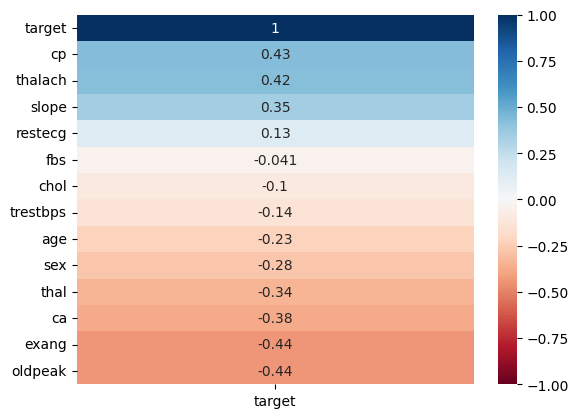

In [136]:
df_corr = df.corr()[['target']].sort_values(by = 'target',ascending = False)
print(df_corr)
sns.heatmap(df_corr,annot=True,cmap='RdBu',center=0, vmax=1, vmin=-1)
plt.show()

## Analysis of Age vs. Maximum Heart Rate (Thalach)

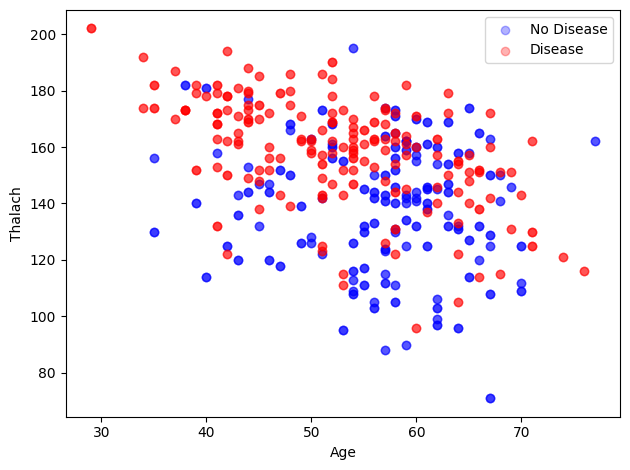

In [160]:
df0 = df[df['target'] == 0]
df1 = df[df['target'] == 1]

plt.scatter(df0['age'], df0['thalach'], color='blue', label='No Disease',alpha=0.3)
plt.scatter(df1['age'], df1['thalach'], color='red', label='Disease',alpha=0.3)

plt.xlabel('Age')
plt.ylabel('Thalach')
plt.legend()
plt.tight_layout()
plt.show()

* This scatter plot visualizes the distribution of patients based on their **Age** and **Maximum Heart Rate (Thalach)**, categorized by their heart disease status.

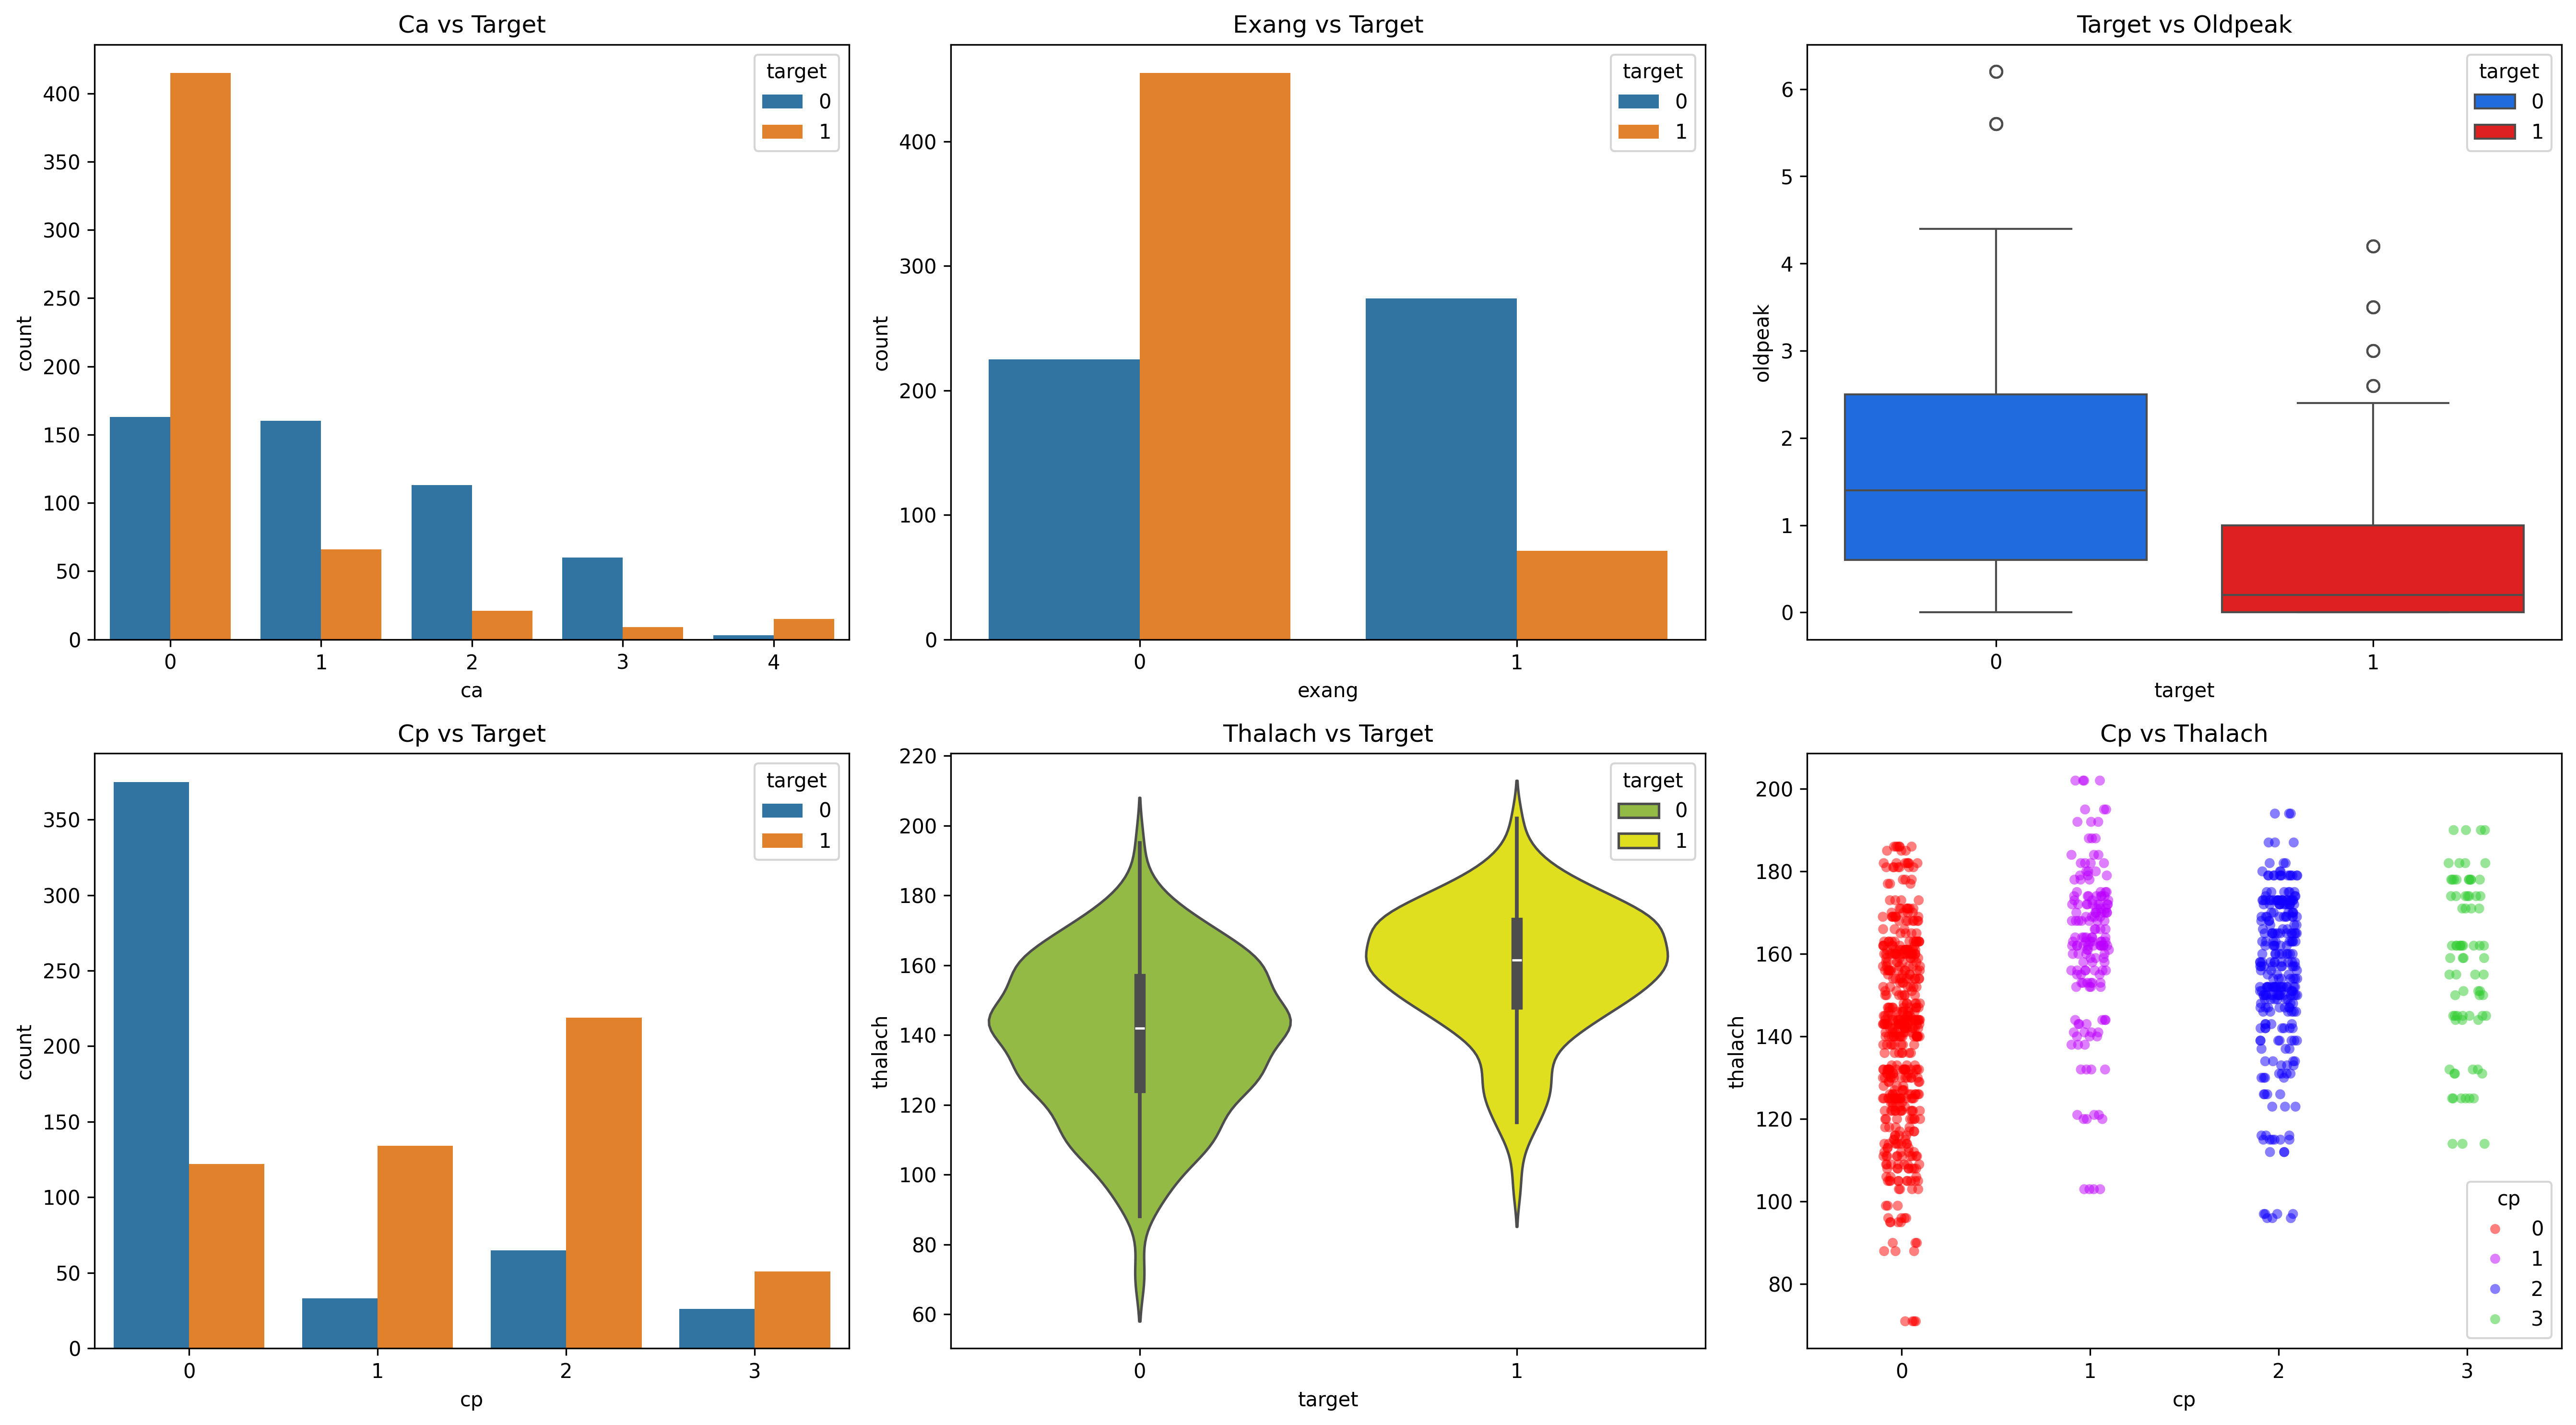

In [159]:
plt.subplots(2, 3, figsize=(18,10),dpi=300)

plt.subplot(2,3,1)
sns.countplot(data=df, x='ca', hue='target')
plt.title('Ca vs Target')

plt.subplot(2,3,2)
sns.countplot(data=df, x='exang', hue='target')
plt.title('Exang vs Target')

plt.subplot(2,3,3)
sns.boxplot(data=df, x='target', y='oldpeak',hue='target', palette={0:'#0066FF',1:'#FF0000'})
plt.title('Target vs Oldpeak')

plt.subplot(2,3,4)
sns.countplot(data=df, x='cp', hue='target')
plt.title('Cp vs Target')

plt.subplot(2,3,5)
sns.violinplot(data=df, x='target', y='thalach', hue='target',palette={0:'#9ACD32',1:'#FFFF00'})
plt.title('Thalach vs Target')

plt.subplot(2,3,6)
sns.stripplot(data=df, x='cp', y='thalach',hue='cp',palette={0:'#FF0000',1:'#BC00FF',2:'#1100FF',3:'#32CD32'},alpha=0.5)
plt.title('Cp vs Thalach')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) Insights

### The above visualizations provide key insights into the relationship between various clinical features and the presence of heart disease.

## 🔹 Key Observations:

* **Ca (Number of Major Vessels):** Lower values of **ca** (specifically 0) are more frequently associated with heart disease in this dataset, suggesting a negative correlation.

* **Exang (Exercise Induced Angina):** Interestingly, the data shows that absence of exercise-induced angina (**exang = 0**) correlates more with a positive heart disease target.

* **Oldpeak (ST Depression):** Lower **oldpeak** values are associated with heart disease patients, which is consistent with the negative correlation of -0.43.

* **Cp (Chest Pain Type):** Higher categories of chest pain types (especially atypical angina or non-anginal pain) show a very strong positive association with heart disease.

* **Thalach (Maximum Heart Rate):** The data indicates that patients with heart disease often have **higher** maximum heart rates compared to those without.

##  Usefull features
 * cp
 * thalach
 * slope
 * age
 * sex
 * ca
 * exang
 * oldpeak
 * thal

In [139]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [140]:
X=df.iloc[:,[0,1,2,7,8,9,10,11,12]]
y=df['target']

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### DecisionTree Classifiere

In [142]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [143]:
y_pred_dt = dt.predict(X_test)

In [144]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


### RandomForest Classifier

In [145]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [146]:
y_pred_rf = rf.predict(X_test)

In [147]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


### Decision Tree vs Random Forest

In [148]:
results = pd.DataFrame({
    'Model': ['Decision Tree','Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.985366        1.0  0.970874  0.985222
1  Random Forest  0.985366        1.0  0.970874  0.985222


## Model Selection Justification: Random Forest

In this project, both the Decision Tree and Random Forest models were trained and evaluated on the heart disease dataset. It was observed that both models achieved identical performance metrics:

#### Accuracy: 98.53%
#### Precision: 1.00
#### Recall: 0.97
#### F1 Score: 0.98

## Why Choose Random Forest? (Brief Explanation)

Even with identical scores, Random Forest is preferred for the following reasons:

1. **Stability:** Decision Trees are sensitive to small data changes, whereas Random Forest is more stable as it averages results from multiple trees.
2. **Generalization:** Random Forest is better at predicting unseen data and handles "noise" or outliers more effectively.
3. **Reduced Risk:** It minimizes the risk of overfitting, which is common in a single, deep Decision Tree.
4. **Reliability:** For medical predictions, an ensemble model like Random Forest is considered more robust and trustworthy.

## Overfitting Check: Train vs. Test Accuracy

In [149]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9853658536585366


* **Training Accuracy:** 1.0 (100%)
* **Testing Accuracy:** 0.985 (98.5%)

### 🔍 Quick Insights:
1. **Perfect Fit:** The 100% training accuracy indicates the model has perfectly captured the patterns (and potentially some noise) within the training data.
2. **Strong Generalization:** Since the test accuracy is nearly identical (98.5%), it proves the model generalizes exceptionally well to unseen data.
3. **Conclusion:** The model is highly reliable and ready for deployment, as there is no significant gap suggesting problematic overfitting.

## F1 Score Analysis: Train vs. Test

In [150]:
print("Train F1:", f1_score(y_train, train_pred))
print("Test F1:", f1_score(y_test, test_pred))

Train F1: 1.0
Test F1: 0.9852216748768473


* **Training F1 Score:** 1.0 (100%)
* **Testing F1 Score:** 0.985 (98.5%)

### 🔍 Quick Insights:
1. **Perfect Balance:** An F1 Score of 1.0 on the training set shows that the model achieved a perfect balance between **Precision** and **Recall**, identifying every case correctly without any errors.
2. **Consistent Performance:** The high testing F1 score (98.5%) confirms that the model is not just guessing; it is highly effective at maintaining a balance between catching all positive cases and avoiding false alarms on new data.
3. **Conclusion:** These results indicate a very robust model that performs consistently across both training and unseen datasets.

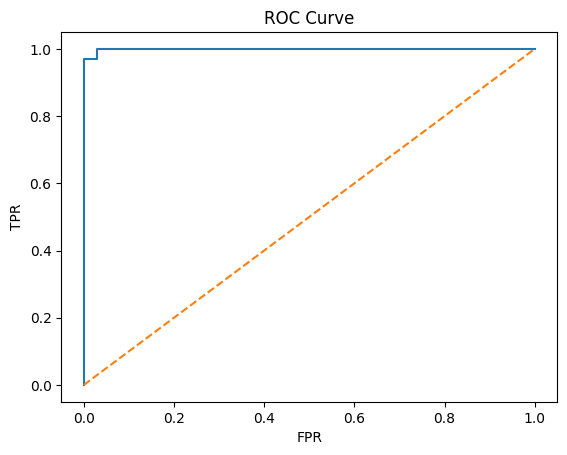

AUC: 0.999143346659052


In [151]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()
print("AUC:", roc_auc_score(y_test, y_prob))